In [27]:
import pandas as pd
pages = ['gss1', 'gss2', 'gss3', 'gss4', 'gss5', 'gss6', 'gss7','gss8', 'gss9', 'gss10']

from bs4 import BeautifulSoup

def extract_gss_variables(html_data):
    soup = BeautifulSoup(html_data, 'html.parser')
    results = []

    # Find all variable name links
    # Based on the HTML: <a class="tt-name" ...>speduc</a>
    var_links = soup.find_all('a', class_='tt-name')

    for link in var_links:
        try:
        # 1. Get the Variable Name
            var_name = link.get_text(strip=True)

            # 2. Get the Description
            # The description is in the next <div> with class 'col-3'
            # Logic: find the parent <div class="col-2"> then find the next sibling <div>
            parent_div = link.find_parent('div', class_='col-2')
            if parent_div:
                desc_div = parent_div.find_next_sibling('div', class_='col-3')
                description = desc_div.get_text(strip=True) if desc_div else "No description found"
                description = description.replace('\n', '')
                description = description.replace('\t', '')
                results.append((var_name, description))
        except Exception as e:
            print(f"Error processing variable {var_name}: {e}")
    return results

# --- HOW TO USE ---
# If you have the full HTML saved in a file named 'gss_page.html':
try:
    variables = []
    for page in pages:
        try:
            with open(page, 'r', encoding='utf-8') as f:
                html_content = f.read()
            
            variables.extend(extract_gss_variables(html_content))
        except FileNotFoundError:
            print(f"Warning: File {page} not found. Skipping this page.")

    print(f"Successfully found {len(variables)} variables:\n")
    print(f"{'Variable':<15} | {'Description'}")
    print("-" * 60)
    for var, desc in variables:
            print(f"{var:<15} | {desc}")

except FileNotFoundError:
    print("Error: Please save your raw HTML to a file named 'gss_page.html' first.")

# save as gss_politicial.csv
variables_df = pd.DataFrame(variables, columns=['Variable', 'Description'])
# dedup by Variable
variables_df = variables_df.drop_duplicates(subset=['Variable'])
# order by Variable
variables_df = variables_df.sort_values(by=['Variable'])
# print length
print(f"\nTotal unique variables: {len(variables_df)}")
variables_df.to_csv('gss_politicial.csv', index=False)


Successfully found 615 variables:

Variable        | Description
------------------------------------------------------------
wrkslf          | r self-emp or works for somebody
marital         | marital status
divorce         | ever been divorced or separated
spwrkslf        | spouse self-emp. or works for somebody
pawrkslf        | Father (or oldest same-sex parent) self-emp.                                                            or worked for somebody
educ            | highest year of school completed
paeduc          | Highest year school completed, father (or                                                            oldest same-sex parent)
maeduc          | Highest year school completed, mother (or                                                            youngest same-sex parent)
speduc          | highest year school completed, spouse
degree          | r's highest degree
padeg           | Father's (or oldest same-sex parent's)                                                  

In [67]:
public_opinion_variables = [
    # Ideological & Identity
    "partyid", "polviews",

    # Government Spending & National Priorities
    "natspac", "natenvir", "natheal", "natcity", "natcrime", "natdrug", 
    "nateduc", "natrace", "natarms", "nataid", "natfare", "natroad", 
    "natsoc", "natspacy", "natenviy", "nathealy", "natcityy", "natcrimy", 
    "natdrugy", "nateducy", "natracey", "natarmsy", "nataidy", "natfarey", 
    "natmass", "natpark", "natsci", "natenrgy", 

    # Role of Government & Economic Policy
    "govchrst", "goveqinc", "goveqinc1", "govfnaid", "govfnanc", 
    "govunemp", "govineq1", "govineq2", "ldctax", "hlthgov",

    # Environmental Policy & Sacrifice
    "busgrn", "carsgen", "grncon", "grnecon", "grnexagg", "grnprog", 
    "grnprice", "grnsol", "grntaxes", "grwtharm", "grwthelp", "harmsgrn", 
    "ihlpgrn", "impgrn", "toodifme", "othssame", 

    # Institutional Confidence & Science
    "conbus", "conclerg", "coneduc", "confed", "conjudge", "conlegis", 
    "conarmy", "confinan", "consci", "scienthe",

    # Civil Liberties & Freedom of Speech
    "spkath", "colath", "libath", "spkcom", "colcom", "libcom", 
    "spkrac", "colrac", "librac", "spkhomo", "colhomo", "libhomo", 
    "spkmslm", "colmslm", "libmslm", "spkmil", "colmil", "libmil",
    "spkathy", "libathy", "spkcomy", "spkhomoy", "spkmily", "spkmslmy", "spkracy",

    # Police Authority & Use of Force
    "polhitok", "polabuse", "polmurdr", "polescap", "polattak",

    # Societal Issues, Laws & Public Ethics
    "cappun", "gunlaw", "courts", "grass", "eqwlth", "prayer", 
    "sexeduc", "pillok", "spanking", "letdie1", "letdie1y", "uswary", 
    "getahead", "getaheadnv", "getaheadv", "helpful", "helpfulnv", "helpfulv",
    "religinf",  "eldfnce",

    # Racial & Gender Equity
    "racopen", "helppoor", "helpnot", "helpsick", "helpblk", 
    "racdif1", "racdif2", "racdif3", "racdif4", "wlthwhts", "workwhts", 
    "discaff", "affrmact", "wrkwayup", "intlwhts", "fejobaff", "discaffm", 
    "fehire", "natchld", "marasian", "marwht", "marblk", "marhisp", 
    "discaffw",

    # Reproductive Rights & Social Action
    "abdefect", "abnomore", "abhlth", "abpoor", "abrape", "absingle", 
    "abany", "abhelp1", "abhelp2", "abhelp3", "abhelp4"
]


# filter variable df by opinion_variabls
opinion_df = variables_df[variables_df['Variable'].isin(public_opinion_variables)]

opinion_df.to_csv('gss_public_opinion.csv', index=False)


In [68]:
len(public_opinion_variables)

151

In [69]:
import pandas as pd

df = pd.read_stata('../../data/gss/GSS2021.dta', convert_categoricals=False)
# enrich id with year
df['id'] = df['id'].astype(str) + '_2021'


In [70]:
import pandas as pd
import re

# 2. Files to process
files = ['../../data/gss/GSS2021.dta', '../../data/gss/GSS2022.dta', '../../data/gss/GSS2024.dta']

def load_and_process_gss(file_list, target_vars):
    all_dfs = []
    
    for file_path in file_list:
        print(f"Processing {file_path}...")
        
        # Extract the year from the filename (e.g., '2021' from '../../data/gss/GSS2021.dta')
        year_match = re.search(r'\d{4}', file_path)
        year_str = year_match.group() if year_match else "Unknown"
        
        # Load the data
        df = pd.read_stata(file_path, convert_categoricals=False)
        
        # --- YOUR ENRICHMENT LOGIC ---
        # Ensure 'id' exists before modifying
        if 'id' in df.columns:
            df['id'] = df['id'].astype(str) + '_' + year_str
        
        # Filter for existing variables (plus the new 'id' and 'year')
        # We use 'year' as a column to make grouping by year easier later
        df['year_label'] = year_str
        cols_to_extract = ['id', 'year_label'] + [v for v in target_vars if v in df.columns]
        
        all_dfs.append(df[cols_to_extract])

    # Combine all years into one DataFrame
    combined_df = pd.concat(all_dfs, ignore_index=True)
    return combined_df

# Execute
df = load_and_process_gss(files, public_opinion_variables)

print("\nProcessing Complete.")
print(df[['id', 'year_label']].head()) # Preview the unique IDs

Processing GSS2021.dta...
Processing GSS2022.dta...


/var/folders/7c/fdmjc9kj7mxgtjskmcwnytxm0000gn/T/ipykernel_76168/3414652190.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year_label'] = year_str
/var/folders/7c/fdmjc9kj7mxgtjskmcwnytxm0000gn/T/ipykernel_76168/3414652190.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year_label'] = year_str


Processing GSS2024.dta...

Processing Complete.
       id year_label
0  1_2021       2021
1  2_2021       2021
2  3_2021       2021
3  4_2021       2021
4  6_2021       2021


/var/folders/7c/fdmjc9kj7mxgtjskmcwnytxm0000gn/T/ipykernel_76168/3414652190.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year_label'] = year_str


In [71]:
df = df[df['partyid'].between(0, 6)]


In [72]:
df.to_csv('gss_2021-2024_public_opinion.csv', index=False)

In [73]:
# Reload the processed data
import pandas as pd
import numpy as np

df = pd.read_csv('gss_2021-2024_public_opinion.csv')
print(f"Loaded {len(df)} respondents")
print(f"Years: {df['year_label'].unique()}")

# Merge duplicate variables (base and 'y' suffix are same question on different ballots)
DUPLICATE_PAIRS = [
    ('natspac', 'natspacy'),
    ('natenvir', 'natenviy'),
    ('natheal', 'nathealy'),
    ('natcity', 'natcityy'),
    ('natcrime', 'natcrimy'),
    ('natdrug', 'natdrugy'),
    ('nateduc', 'nateducy'),
    ('natrace', 'natracey'),
    ('natarms', 'natarmsy'),
    ('nataid', 'nataidy'),
    ('natfare', 'natfarey'),
    ('letdie1', 'letdie1y'),
]

for base, alt in DUPLICATE_PAIRS:
    if base in df.columns and alt in df.columns:
        # Combine: use base if available, otherwise use alt
        df[base] = df[base].combine_first(df[alt])
        df = df.drop(columns=[alt])
        print(f"  Merged {alt} into {base}")
    elif alt in df.columns and base not in df.columns:
        # Rename alt to base
        df = df.rename(columns={alt: base})
        print(f"  Renamed {alt} to {base}")

print(f"\nColumns after merging: {len(df.columns)}")
print(f"Party ID distribution:\n{df['partyid'].value_counts().sort_index()}")

Loaded 11066 respondents
Years: [2021 2022 2024]
  Merged natspacy into natspac
  Merged natenviy into natenvir
  Merged nathealy into natheal
  Merged natcityy into natcity
  Merged natcrimy into natcrime
  Merged natdrugy into natdrug
  Merged nateducy into nateduc
  Merged natracey into natrace
  Merged natarmsy into natarms
  Merged nataidy into nataid
  Merged natfarey into natfare
  Merged letdie1y into letdie1

Columns after merging: 141
Party ID distribution:
partyid
0.0    2064
1.0    1506
2.0    1290
3.0    2617
4.0     967
5.0    1179
6.0    1443
Name: count, dtype: int64


In [75]:
# Polarization calculation functions

def create_party_groups(df, partyid_col='partyid'):
    """
    Create party group labels from partyid (0-6 scale).
    0-2: Democrat (Strong Dem, Not Strong Dem, Ind Near Dem)
    3: Independent
    4-6: Republican (Ind Near Rep, Not Strong Rep, Strong Rep)
    """
    df = df.copy()
    conditions = [
        df[partyid_col].between(0, 2),
        df[partyid_col] == 3,
        df[partyid_col].between(4, 6)
    ]
    choices = ['Democrat', 'Independent', 'Republican']
    df['party_group'] = np.select(conditions, choices, default=np.nan)
    return df

def calculate_polarization(df, question_col, partyid_col='partyid', min_responses=30):
    """
    Calculate normalized partisan gap for a single question.
    
    Returns dict with:
    - polarization: normalized |mean_dem - mean_rep| / scale_range
    - mean_dem, mean_rep: raw means
    - n_dem, n_rep: sample sizes
    - direction: 'Dem higher' or 'Rep higher'
    """
    # Filter valid responses (>= 1 excludes typical GSS missing codes like 0, 8, 9, -1)
    # Adjust this filter based on your specific variable coding
    valid = df[[partyid_col, question_col]].dropna()
    valid = valid[valid[question_col] >= 1]
    
    # For most GSS opinion vars, valid responses are 1-4 or 1-3
    # Exclude high values that typically mean DK/NA (8, 9, etc.)
    max_valid = valid[question_col].quantile(0.95)  # Use 95th percentile as heuristic
    if max_valid <= 7:
        valid = valid[valid[question_col] <= 7]
    
    # Create party groups
    valid = create_party_groups(valid, partyid_col)
    valid = valid[valid['party_group'].isin(['Democrat', 'Republican'])]
    
    # Calculate means by party
    grouped = valid.groupby('party_group')[question_col]
    means = grouped.mean()
    counts = grouped.count()
    
    # Check minimum sample sizes
    if 'Democrat' not in means.index or 'Republican' not in means.index:
        return None
    if counts['Democrat'] < min_responses or counts['Republican'] < min_responses:
        return None
    
    mean_dem = means['Democrat']
    mean_rep = means['Republican']
    
    # Calculate scale range from valid data
    scale_min = valid[question_col].min()
    scale_max = valid[question_col].max()
    scale_range = scale_max - scale_min
    
    if scale_range == 0:
        return None
    
    # Normalized polarization (0-1 scale)
    polarization = abs(mean_dem - mean_rep) / scale_range
    
    return {
        'polarization': polarization,
        'mean_dem': mean_dem,
        'mean_rep': mean_rep,
        'n_dem': counts['Democrat'],
        'n_rep': counts['Republican'],
        'n_total': counts['Democrat'] + counts['Republican'],
        'scale_range': scale_range,
        'direction': 'Dem higher' if mean_dem > mean_rep else 'Rep higher'
    }

print("Polarization functions defined.")

Polarization functions defined.


In [78]:
TOPIC_GROUPS = {
    # =========================
    # POLITICS & PRIORITIES
    # =========================

    # =========================
    # REPRODUCTIVE RIGHTS
    # =========================
    'Abortion: Circumstances for Legality & Support': [
        'abdefect', 'abnomore', 'abhlth', 'abpoor', 'abrape', 'absingle', 'abany',
        'abhelp1', 'abhelp2', 'abhelp3', 'abhelp4', # Willingness to help/support
    ],
    
    'Teens: Birth Control Access': [
        'pillok',
    ],

    # =========================
    # ENVIRONMENT
    # =========================
    'Spending: Environment & Energy': [
        'natenvir', 'natenrgy', 'natpark',
    ],
    
    'Environment: Regulation & Personal Sacrifice': [
        'busgrn', 'carsgen', 'grncon', 'grnecon', 'grnexagg', 'grnprog', 
        'grnprice', 'grnsol', 'grntaxes', 'grwtharm', 'grwthelp', 'harmsgrn', 
        'ihlpgrn', 'impgrn', 'toodifme', 'othssame', 'peopgrn',
    ],

    # =========================
    # JUSTICE & AUTHORITY
    # =========================
    'Criminal Justice: Punishment & Drug Policy': [
        'cappun', 'gunlaw', 'courts', 'grass',
    ],
    
    'Spending: Crime & Drug Enforcement': [
        'natcrime', 'natdrug',
    ],
    
    'Police Authority: Use of Force': [
        'polhitok', 'polabuse', 'polmurdr', 'polescap', 'polattak',
    ],

    # =========================
    # RACE & EQUITY
    # =========================
    'Race: Explanations for Inequality': [
        'racdif1', 'racdif2', 'racdif3', 'racdif4',
    ],
    
    'Race: Government Intervention & Affirmative Action': [
        'helpblk', 'wrkwayup', 'affrmact', 'discaff', 'natrace',
    ],
    
    'Race: Perceived Group Differences & Social Distance': [
        'wlthwhts', 'workwhts', 'intlwhts', 'racopen', 
        'marasian', 'marwht', 'marblk', 'marhisp', # Intermarriage
    ],

    # =========================
    # GOVERNMENT ROLE & ECONOMICS
    # =========================
    'Spending: Welfare, Education & Infrastructure': [
        'natfare', 'nateduc', 'natcity', 'natroad', 'natmass', 'natchld',
    ],

    'Welfare & Redistribution Policy': [
        'helppoor', 'helpnot', 'eqwlth',
    ],

    'Role of Government: Economics & Global Aid': [
        'goveqinc', 'goveqinc1', 'govfnaid', 'govfnanc', 'govunemp', 
        'govineq1', 'govineq2', 'ldctax',
    ],

    'Economic Mobility: Effort vs. Luck': [
        'getahead', # Includes variants getaheadnv/v
    ],

    # =========================
    # INSTITUTIONAL CONFIDENCE
    # =========================
    'Confidence: Government (Executive, Congress, Courts)': [
        'confed', 'conjudge', 'conlegis',
    ],
    
    'Confidence: Business, Finance & Military': [
        'conbus', 'confinan', 'conarmy',
    ],
    
    'Confidence: Science & Research': [
        'consci', 'scienthe', 'natspac', 'natsci',
    ],
    
    'Confidence: Education System': [
        'coneduc',
    ],
    
    'Confidence: Clergy': [
        'conclerg',
    ],
    
    'Social Trust': [
        'helpful', # Includes variants helpfulnv/v
    ],

    # =========================
    # EDUCATION & SCHOOLS
    # =========================
    'Schools: Policy & Religion': [
        'sexeduc', 'prayer',
    ],

    # =========================
    # CIVIL LIBERTIES & TOLERANCE
    # =========================
    'Tolerance: Anti-Religious Expression': [
        'spkath', 'colath', 'libath',
    ],
    
    'Tolerance: Pro-Homosexual Expression': [
        'spkhomo', 'colhomo', 'libhomo',
    ],
    
    'Tolerance: Communist Expression': [
        'spkcom', 'colcom', 'libcom',
    ],
    
    'Tolerance: Racist Expression': [
        'spkrac', 'colrac', 'librac',
    ],
    
    'Tolerance: Muslim Extremist Expression': [
        'spkmslm', 'colmslm', 'libmslm',
    ],

    'Tolerance: Militarist Expression': [
        'spkmil', 'colmil', 'libmil',
    ],

    # =========================
    # SOCIAL ISSUES & ETHICS
    # =========================
    'Gender: Workplace Hiring & Affirmative Action': [
        'fejobaff', 'fehire', 'discaffw', 'discaffm',
    ],
    
    'Religion in Public Life': [
        'govchrst', 'religinf',
    ],

    'Bioethics & End of Life': [
        'letdie1',
    ],
    
    'Parenting: Corporal Punishment': [
        'spanking',
    ],
    
    'Family Responsibility: Care for Elderly': [
        'eldfnce',
    ],

    'Military & Foreign Aid': [
        'natarms', 'nataid', 'uswary',
    ],

    'Spending: Social Security': [
        'natsoc',
    ],
}

In [79]:
# Create reverse mapping: variable -> topic
VAR_TO_TOPIC = {}
for topic, variables in TOPIC_GROUPS.items():
    for var in variables:
        VAR_TO_TOPIC[var] = topic

print(f"Defined {len(TOPIC_GROUPS)} topic groups with {len(VAR_TO_TOPIC)} total variables\n")
for topic, vars in TOPIC_GROUPS.items():
    print(f"  [{len(vars)}] {topic}")

Defined 34 topic groups with 124 total variables

  [11] Abortion: Circumstances for Legality & Support
  [1] Teens: Birth Control Access
  [3] Spending: Environment & Energy
  [17] Environment: Regulation & Personal Sacrifice
  [4] Criminal Justice: Punishment & Drug Policy
  [2] Spending: Crime & Drug Enforcement
  [5] Police Authority: Use of Force
  [4] Race: Explanations for Inequality
  [5] Race: Government Intervention & Affirmative Action
  [8] Race: Perceived Group Differences & Social Distance
  [6] Spending: Welfare, Education & Infrastructure
  [3] Welfare & Redistribution Policy
  [8] Role of Government: Economics & Global Aid
  [1] Economic Mobility: Effort vs. Luck
  [3] Confidence: Government (Executive, Congress, Courts)
  [3] Confidence: Business, Finance & Military
  [4] Confidence: Science & Research
  [1] Confidence: Education System
  [1] Confidence: Clergy
  [1] Social Trust
  [2] Schools: Policy & Religion
  [3] Tolerance: Anti-Religious Expression
  [3] Toleran

In [80]:
# giant list of topics in TOPIC_GROUPS
l = []
print("List of Topics:")
for topic in TOPIC_GROUPS.keys():
    l.extend(TOPIC_GROUPS[topic])
print(len(l), "variables in total.\n")
l

List of Topics:
124 variables in total.



['abdefect',
 'abnomore',
 'abhlth',
 'abpoor',
 'abrape',
 'absingle',
 'abany',
 'abhelp1',
 'abhelp2',
 'abhelp3',
 'abhelp4',
 'pillok',
 'natenvir',
 'natenrgy',
 'natpark',
 'busgrn',
 'carsgen',
 'grncon',
 'grnecon',
 'grnexagg',
 'grnprog',
 'grnprice',
 'grnsol',
 'grntaxes',
 'grwtharm',
 'grwthelp',
 'harmsgrn',
 'ihlpgrn',
 'impgrn',
 'toodifme',
 'othssame',
 'peopgrn',
 'cappun',
 'gunlaw',
 'courts',
 'grass',
 'natcrime',
 'natdrug',
 'polhitok',
 'polabuse',
 'polmurdr',
 'polescap',
 'polattak',
 'racdif1',
 'racdif2',
 'racdif3',
 'racdif4',
 'helpblk',
 'wrkwayup',
 'affrmact',
 'discaff',
 'natrace',
 'wlthwhts',
 'workwhts',
 'intlwhts',
 'racopen',
 'marasian',
 'marwht',
 'marblk',
 'marhisp',
 'natfare',
 'nateduc',
 'natcity',
 'natroad',
 'natmass',
 'natchld',
 'helppoor',
 'helpnot',
 'eqwlth',
 'goveqinc',
 'goveqinc1',
 'govfnaid',
 'govfnanc',
 'govunemp',
 'govineq1',
 'govineq2',
 'ldctax',
 'getahead',
 'confed',
 'conjudge',
 'conlegis',
 'conbus',


In [81]:
# Calculate polarization for all opinion variables

# Get all opinion variable columns (exclude id, year_label, partyid)
opinion_cols = [col for col in df.columns if col not in ['id', 'year_label', 'partyid']]

# Calculate polarization for each variable
results = []
for col in opinion_cols:
    pol_result = calculate_polarization(df, col)
    if pol_result is not None:
        results.append({
            'variable': col,
            'area': VAR_TO_TOPIC.get(col, 'Other'),
            **pol_result
        })

# Create results DataFrame
polarization_df = pd.DataFrame(results)
polarization_df = polarization_df.sort_values('polarization', ascending=False)

print(f"Calculated polarization for {len(polarization_df)} variables")
print(f"\nTop 15 most polarizing questions:")
print(polarization_df[['variable', 'area', 'polarization', 'direction', 'n_total']].head(15).to_string(index=False))

Calculated polarization for 138 variables

Top 15 most polarizing questions:
 variable                                               area  polarization  direction  n_total
  racdif1                  Race: Explanations for Inequality      0.562443 Rep higher     3770
  abhelp2     Abortion: Circumstances for Legality & Support      0.472126 Rep higher      913
 abnomore     Abortion: Circumstances for Legality & Support      0.470704 Rep higher     3191
    abany     Abortion: Circumstances for Legality & Support      0.462417 Rep higher     3571
   abpoor     Abortion: Circumstances for Legality & Support      0.446558 Rep higher     3212
 absingle     Abortion: Circumstances for Legality & Support      0.443313 Rep higher     3205
  abhelp3     Abortion: Circumstances for Legality & Support      0.439301 Rep higher      918
  natrace Race: Government Intervention & Affirmative Action      0.418868 Rep higher     8134
  helpblk Race: Government Intervention & Affirmative Action      0.

In [82]:
# Aggregate polarization by topic

topic_polarization = polarization_df.groupby('area').agg({
    'polarization': ['mean', 'std', 'count'],
    'n_total': 'mean'
}).round(3)

# Flatten column names
topic_polarization.columns = ['mean_polarization', 'std_polarization', 'n_questions', 'avg_sample_size']
topic_polarization = topic_polarization.sort_values('mean_polarization', ascending=False)

print("Polarization by Topic Area:")
print("=" * 70)
print(topic_polarization.to_string())

# Also show which topics have the most consistent polarization (low std)
print("\n\nTopics by Consistency (lowest std = most consistent across questions):")
print(topic_polarization.sort_values('std_polarization')[['mean_polarization', 'std_polarization', 'n_questions']].to_string())

Polarization by Topic Area:
                                                      mean_polarization  std_polarization  n_questions  avg_sample_size
area                                                                                                                   
Race: Government Intervention & Affirmative Action                0.347             0.078            5         6566.600
Welfare & Redistribution Policy                                   0.347             0.059            3         5546.667
Abortion: Circumstances for Legality & Support                    0.344             0.139           11         2411.091
Race: Explanations for Inequality                                 0.303             0.236            4         3776.250
Religion in Public Life                                           0.302             0.015            2         3530.500
Role of Government: Economics & Global Aid                        0.247             0.124            8         1372.375
Criminal Jus

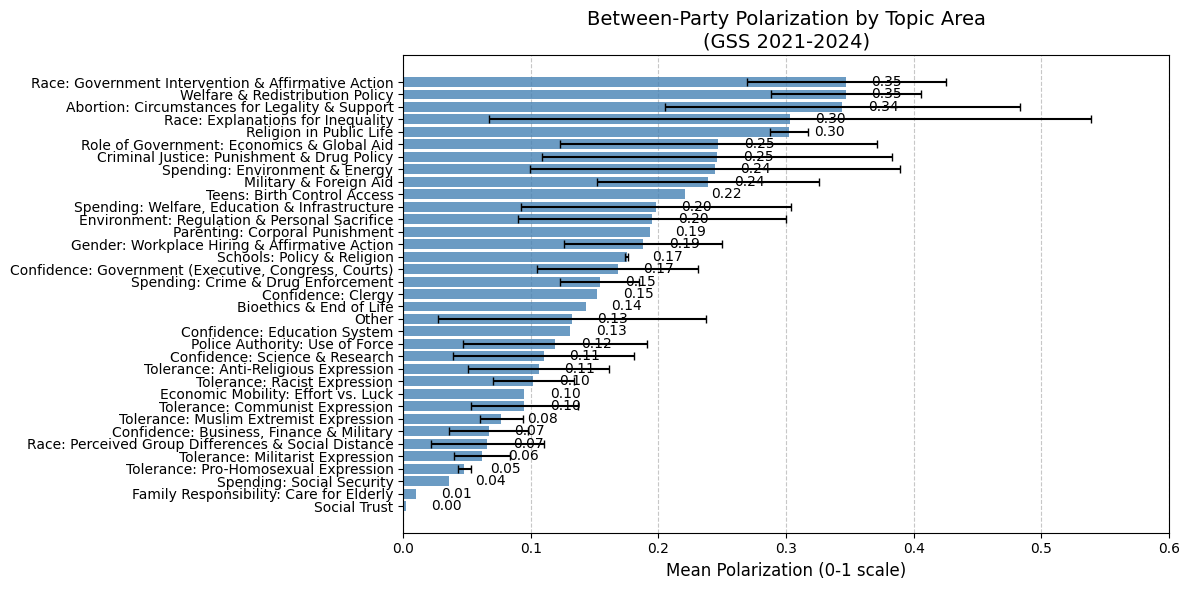

In [83]:
# Visualization: Bar chart of polarization by topic
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Sort for plotting
plot_data = topic_polarization.sort_values('mean_polarization', ascending=True)

# Create horizontal bar chart
bars = ax.barh(plot_data.index, plot_data['mean_polarization'], 
               xerr=plot_data['std_polarization'], capsize=3,
               color='steelblue', alpha=0.8)

ax.set_xlabel('Mean Polarization (0-1 scale)', fontsize=12)
ax.set_title('Between-Party Polarization by Topic Area\n(GSS 2021-2024)', fontsize=14)
ax.set_xlim(0, 0.6)

# Add value labels
for i, (idx, row) in enumerate(plot_data.iterrows()):
    ax.text(row['mean_polarization'] + 0.02, i, f"{row['mean_polarization']:.2f}", 
            va='center', fontsize=10)

# Add gridlines
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

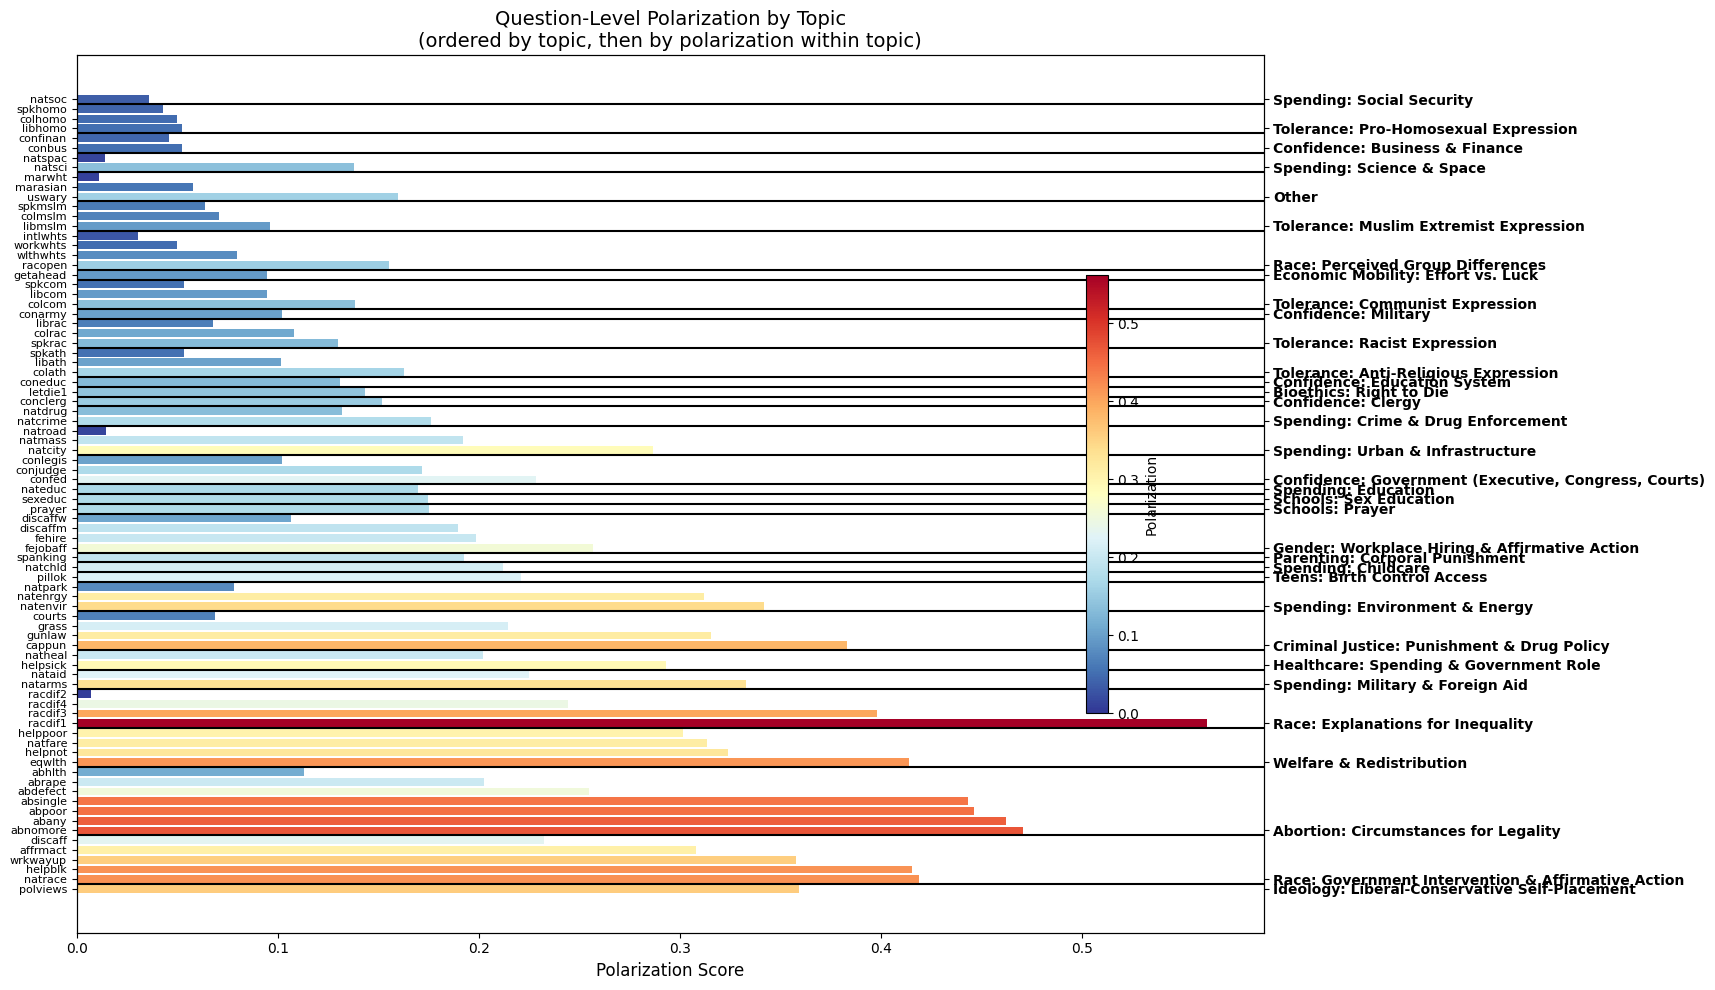

In [9]:
# Visualization: Heatmap of individual questions colored by polarization
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for heatmap - show top questions per topic
fig, ax = plt.subplots(figsize=(14, 10))

# Sort topics by mean polarization, then sort questions within each topic
sorted_topics = topic_polarization.sort_values('mean_polarization', ascending=False).index.tolist()

# Create ordered list of questions grouped by topic
ordered_data = []
for topic in sorted_topics:
    topic_vars = polarization_df[polarization_df['area'] == topic].sort_values('polarization', ascending=False)
    for _, row in topic_vars.iterrows():
        ordered_data.append(row)

ordered_df = pd.DataFrame(ordered_data)

# Create the heatmap-style horizontal bar chart
colors = plt.cm.RdYlBu_r(ordered_df['polarization'] / ordered_df['polarization'].max())

y_positions = range(len(ordered_df))
bars = ax.barh(y_positions, ordered_df['polarization'], color=colors, height=0.8)

# Add topic separators and labels
current_topic = None
topic_positions = []
for i, (_, row) in enumerate(ordered_df.iterrows()):
    if row['area'] != current_topic:
        if current_topic is not None:
            ax.axhline(y=i - 0.5, color='black', linewidth=1.5)
        topic_positions.append((i, row['area']))
        current_topic = row['area']

# Labels
ax.set_yticks(y_positions)
ax.set_yticklabels(ordered_df['variable'], fontsize=8)
ax.set_xlabel('Polarization Score', fontsize=12)
ax.set_title('Question-Level Polarization by Topic\n(ordered by topic, then by polarization within topic)', fontsize=14)

# Add topic labels on the right side
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks([pos for pos, _ in topic_positions])
ax2.set_yticklabels([topic for _, topic in topic_positions], fontsize=10, fontweight='bold')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=plt.Normalize(0, ordered_df['polarization'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.15, shrink=0.5)
cbar.set_label('Polarization', fontsize=10)

plt.tight_layout()
plt.show()

In [84]:
# Save polarization results to CSV
polarization_df.to_csv('gss_polarization.csv', index=False)
topic_polarization.to_csv('gss_polarization_by_topic.csv')

print("Saved results to:")
print("  - gss_polarization_by_question.csv (question-level)")
print("  - gss_polarization_by_topic.csv (topic-level)")

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Total questions analyzed: {len(polarization_df)}")
print(f"Total topics: {len(topic_polarization)}")
print(f"\nMost polarizing topic: {topic_polarization['mean_polarization'].idxmax()} ({topic_polarization['mean_polarization'].max():.3f})")
print(f"Least polarizing topic: {topic_polarization['mean_polarization'].idxmin()} ({topic_polarization['mean_polarization'].min():.3f})")
print(f"\nMost polarizing question: {polarization_df.iloc[0]['variable']} ({polarization_df.iloc[0]['polarization']:.3f})")
print(f"Least polarizing question: {polarization_df.iloc[-1]['variable']} ({polarization_df.iloc[-1]['polarization']:.3f})")

Saved results to:
  - gss_polarization_by_question.csv (question-level)
  - gss_polarization_by_topic.csv (topic-level)

SUMMARY
Total questions analyzed: 138
Total topics: 35

Most polarizing topic: Race: Government Intervention & Affirmative Action (0.347)
Least polarizing topic: Social Trust (0.002)

Most polarizing question: racdif1 (0.562)
Least polarizing question: helpful (0.002)
